# CE49X Lab 4: Istanbul Earthquake Risk Communication Dashboard
## Visualization for Decision-Makers

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Group Members:**
| Name | Student ID |
|------|------------|
| Hamza Barış Örnek| 2021403201 |
| Ali Şeker | 2021403012 |

## Background

Istanbul sits directly on the **North Anatolian Fault (NAF)**, one of the most active strike-slip faults in the world. The devastating 1999 Izmit earthquake (M7.6) ruptured a segment just 80 km east of the city, and seismologists have long warned that the next major rupture is expected beneath the Sea of Marmara — directly south of Istanbul.

The 2023 Kahramanmaras earthquake sequence (M7.8 + M7.5) demonstrated the catastrophic potential of large earthquakes in Turkey and renewed urgency around earthquake preparedness in Istanbul, a city of over 16 million people.

Effective **risk communication** is critical: decision-makers in municipal government need clear, honest, and actionable visualizations — not just raw data. A misleading colormap or a truncated axis can distort risk perception and lead to poor resource allocation.

> **Key Insight:** Visualization is not decoration — it is a critical tool for communicating risk to non-technical audiences. Every design choice (color, scale, annotation) shapes how decision-makers understand and act on data.

## Scenario

You have been hired as a **visualization consultant** for Istanbul's Disaster Coordination Center (AFAD Istanbul). Your task is to create a set of **publication-quality visualizations** for a risk communication report that will be presented to the **Istanbul Municipal Council** — a non-technical audience of elected officials who must decide how to allocate earthquake preparedness funding across Istanbul's districts.

Your visualizations must be:
- **Accurate** — no misleading scales, truncated axes, or rainbow colormaps
- **Clear** — interpretable by someone without a seismology background
- **Actionable** — each chart should support a specific decision or insight
- **Professional** — publication-ready with proper labels, titles, and annotations

## Data Requirements

You must collect **three categories** of real data. No data files are provided — you are responsible for sourcing, downloading, and documenting your data. For each dataset, record the **source URL**, **date accessed**, **how you obtained it**, and **number of records**.

### 1. Earthquake Catalog (required)

Historical earthquakes for the Marmara region. You need **at least 200 earthquakes** with year, latitude, longitude, depth, and magnitude.

Suggested sources:
- **AFAD Earthquake Department**: [deprem.afad.gov.tr](https://deprem.afad.gov.tr) — Turkey's official earthquake catalog, searchable by region/date/magnitude, downloadable as CSV
- **KOERI (Kandilli Observatory)**: [koeri.boun.edu.tr](http://www.koeri.boun.edu.tr) — Bogazici University's own seismology center
- **USGS Earthquake Catalog**: [earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/) — global catalog, CSV export, filter by lat/lon bounding box (e.g., 40-41.5°N, 27-31°E for the Marmara region)

### 2. Building / Population Data (required)

Istanbul district-level data on buildings and/or population. You need data for **at least 10 Istanbul districts** with population and at least one building-related metric (age, type, or count).

Suggested sources:
- **TUIK (Turkish Statistical Institute)**: [data.tuik.gov.tr](https://data.tuik.gov.tr) — district-level population, building permits, construction statistics
- **IBB Open Data Portal**: [data.ibb.gov.tr](https://data.ibb.gov.tr) — Istanbul municipality datasets on buildings, infrastructure, demographics
- **Wikipedia / official district pages** — acceptable for population/area if properly cited

### 3. Seismic Hazard or Vulnerability Data (required)

Any dataset that allows spatial visualization of earthquake risk. You need spatial risk data covering Istanbul (grid, district-level, or at least 10 data points with coordinates).

Options include:
- **AFAD seismic hazard maps** — PGA (Peak Ground Acceleration) values or seismic zones for Istanbul
- **AFAD/IBB building damage estimates** — expected damage scenarios for a major Marmara earthquake
- **Soil classification maps** from IBB or academic papers
- **Any published risk study** with district-level or grid-level data (can be manually digitized from a figure if necessary)

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Collection & Documentation | 10 | Data sourcing, Pandas loading, `df.head()`, `df.describe()` |
| D2 | Historical Seismicity Timeline | 15 | Scatter with variable size/color, colorbar, `annotate` |
| D3 | Magnitude-Frequency Analysis | 15 | Histogram + KDE, `axvline`, log-plot with linear fit |
| D4 | Building Vulnerability or Population Risk | 15 | Seaborn categorical plots, sorted charts, color encoding |
| D5 | Earthquake Hazard Visualization | 20 | `contourf`/scatter/heatmap, sequential colormap, annotations |
| D6 | Multi-Panel Risk Dashboard + Reflection | 25 | `GridSpec`, 3+ chart types, derived metric, `savefig`, written reflection |
| **Total** | | **100** | |

---
## Deliverable 1: Data Collection & Documentation (10 pts)

Load all three collected datasets into Pandas DataFrames. For **each** dataset:

1. **Document the source** — URL, date accessed, how you obtained the data (e.g., "downloaded CSV from USGS search interface with bounding box 40-41.5°N, 27-31°E, all magnitudes, 1900-2026")
2. **Show `df.head()`** to display the first few rows
3. **Show `df.describe()`** to summarize key statistics
4. **Note any cleaning steps** performed (dropping NaN rows, converting date formats, renaming columns, etc.)
5. **Report the number of records** in each dataset

> **Key Insight:** Data provenance matters. A visualization is only as trustworthy as the data behind it. Always document your sources so others can verify and reproduce your work.

---
## Deliverable 2: Historical Seismicity Timeline (15 pts)

Create a **scatter plot** showing historical earthquakes in the Marmara region over time.

**Requirements:**
- **x-axis:** year (or date)
- **y-axis:** magnitude
- **Point size:** proportional to magnitude (larger earthquakes = larger markers)
- **Point color:** mapped to depth using a **sequential colormap** (e.g., `viridis`, `plasma`) with a **colorbar**
- **Annotate** at least 3 major historical earthquakes (e.g., 1999 Izmit M7.6, 1999 Duzce M7.2, 1894 Istanbul earthquake)
- **Title** must state a finding or insight, not just "Earthquake Timeline" (e.g., *"Marmara Region Has Experienced 12 Earthquakes Above M6.0 Since 1900"*)
- Professional styling: axis labels with units, grid, appropriate font sizes

> **Theory Connection:** This deliverable tests your understanding of the **encoding hierarchy** from the theory notebook. You are using position (most accurate channel) for time and magnitude, size for emphasis, and color for an additional variable. Your title should tell a story, not just label the chart.

---
## Deliverable 3: Magnitude-Frequency Analysis (15 pts)

Create **two subplots** (side by side) analyzing the magnitude distribution:

**Subplot 1 — Magnitude Histogram:**
- Histogram of earthquake magnitudes with a **KDE overlay** (use `sns.histplot` with `kde=True` or overlay manually)
- Add **vertical lines** for the mean and median magnitudes (`ax.axvline`) with labels in the legend
- **Justify your bin width choice** in a code comment (e.g., "Using 0.2 magnitude bins because the catalog reports magnitudes to 0.1 precision")

**Subplot 2 — Gutenberg-Richter Plot:**
- Plot **log₁₀(cumulative count)** vs. magnitude
- Fit a **linear regression** to the linear portion of the curve using `np.polyfit`
- Display the **b-value** on the plot (the slope of the fitted line; typical b-values are ~1.0)
- The Gutenberg-Richter law states: $\log_{10} N = a - bM$, where $N$ is the number of earthquakes ≥ magnitude $M$

> **Theory Connection:** This deliverable tests **bin selection** (how bin width affects perception of the distribution) and **data transformation** (log scale to reveal the power-law relationship). The Gutenberg-Richter plot is a classic example of how the right transformation makes a pattern visible.

---
## Deliverable 4: Building Vulnerability or Population Risk (15 pts)

Create **at least 2 subplots** comparing Istanbul districts using your building/population data.

**Requirements:**
- Use at least **one Seaborn categorical plot** (`sns.barplot`, `sns.boxplot`, `sns.violinplot`, or `sns.stripplot`)
- **Sort districts** meaningfully — by vulnerability, population density, building age, or another relevant metric (do NOT use alphabetical order)
- Clean labeling: rotated tick labels if district names overlap, axis labels with units
- Use **color encoding** purposefully (e.g., highlight the most vulnerable districts in a different color)

**Example subplot ideas** (choose based on your data):
- Population density by district (bar chart, sorted descending)
- Building age distribution across districts (boxplot or violin plot)
- Pre-1999 vs. post-1999 building stock by district (grouped bar chart)
- Population vs. building count scatter with district labels

> **Theory Connection:** This deliverable tests the **chart selection framework** from the theory notebook. You must choose the right chart type for your data (categorical vs. quantitative, comparison vs. distribution). It also tests the **data-ink ratio** principle — remove unnecessary chart junk and let the data speak.

---
## Deliverable 5: Earthquake Hazard Visualization (20 pts)

Create a **spatial visualization** of earthquake risk/hazard across Istanbul.

**If you have grid-level data** (e.g., PGA values on a grid):
- Use `ax.contourf()` with contour lines and labels
- Set `aspect='equal'` for correct geographic proportions
- Add a colorbar with a descriptive label (e.g., "Peak Ground Acceleration (g)")

**If you have district-level data:**
- Use a colored scatter/bubble map (marker size or color ∝ risk) or a choropleth-style horizontal bar chart
- Overlay district names or markers at district center coordinates

**Requirements (all approaches):**
- **DO NOT use rainbow/jet colormap** — use a sequential colormap (`YlOrRd`, `Reds`, `inferno`, `OrRd`, etc.) that is perceptually uniform
- Annotate **danger zones** — label or highlight the highest-risk areas
- Include geographic context (label the Bosphorus, Sea of Marmara, or major landmarks if helpful)
- Title should communicate the key finding

> **Theory Connection:** This is the most design-intensive deliverable. It tests your understanding of **why rainbow colormaps are harmful** (they create false boundaries and are not perceptually uniform), the principle of **spatial data → spatial chart**, and the importance of **annotations** for guiding the viewer's attention.

---
## Deliverable 6: Multi-Panel Risk Dashboard + Reflection (25 pts)

### Part A — Dashboard Figure (15 pts)

Create a **single multi-panel figure** that serves as an executive summary for the Municipal Council.

**Requirements:**
- Use `plt.GridSpec` (or `fig.add_gridspec`) to arrange panels — at least **one panel must span multiple grid cells**
- Combine at least **3 different chart types** (e.g., scatter + bar + contourf, or timeline + histogram + heatmap)
- Include at least one **derived metric** that you compute (e.g., population × PGA, vulnerability index = f(building age, soil type), risk score)
- Add an overall `fig.suptitle()` that communicates the main message to the audience
- Save the figure: `fig.savefig('dashboard.png', dpi=300, bbox_inches='tight')`

### Part B — Written Reflection (10 pts)

In a markdown cell, write a reflection addressing **all three** of the following:

1. **Chart type justification:** For each of your visualizations (D2-D5), explain why you chose that chart type. Reference a specific concept from the theory notebook (e.g., encoding hierarchy, chart selection framework, data-ink ratio, Tufte's principles).

2. **Audience adaptation:** How would your visualizations differ if the audience were **seismologists** instead of the municipal council? Give **2 specific examples** of changes you would make (e.g., "I would use PGA units instead of a qualitative risk scale" or "I would show the full Gutenberg-Richter fit residuals").

3. **Self-critique:** Identify your **weakest visualization** and describe how you would improve it. Reference a specific "common mistake" from the theory notebook (e.g., chartjunk, misleading axes, poor color choice, over-plotting).

---
## Hints

### Gutenberg-Richter Fit

To compute the Gutenberg-Richter relationship:

```python
# Sort unique magnitudes
mags = np.sort(df['magnitude'].values)
# For each magnitude M, count earthquakes >= M
unique_mags = np.arange(mags.min(), mags.max(), 0.1)
cumulative_counts = np.array([np.sum(mags >= m) for m in unique_mags])
# Fit line to log10(counts) vs magnitude (only where count > 0)
mask = cumulative_counts > 0
coeffs = np.polyfit(unique_mags[mask], np.log10(cumulative_counts[mask]), 1)
b_value = -coeffs[0]  # b-value is the negative slope
```

### Colormaps

**Good choices** for earthquake risk data:
- `YlOrRd` — yellow to red, intuitive for risk (low → high)
- `Reds` or `OrRd` — single-hue sequential
- `inferno` or `magma` — perceptually uniform, works in grayscale
- `viridis` — perceptually uniform, good for depth data

**Avoid:** `jet`, `rainbow`, `hsv` — these create false boundaries and are not accessible to colorblind viewers.

### GridSpec Layout

```python
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])   # top-left, spans 2 columns
ax2 = fig.add_subplot(gs[0, 2])    # top-right
ax3 = fig.add_subplot(gs[1, 0])    # bottom-left
ax4 = fig.add_subplot(gs[1, 1:])   # bottom-center+right, spans 2 columns
```

### Data-Ink Ratio (Tufte)

> *"Above all else, show the data."* — Edward Tufte

Remove unnecessary gridlines, borders, and decorations. Every drop of ink on your chart should represent data or help the reader interpret data. If an element doesn't serve either purpose, remove it.

### AFAD Query Tips

When downloading from AFAD ([deprem.afad.gov.tr](https://deprem.afad.gov.tr)):
- Use the "Earthquake Catalog" (Deprem Katalogu) search
- Set geographic bounds for the Marmara region: approximately 40.0-41.5°N, 26.5-31.0°E
- Set minimum magnitude to 2.0 or 3.0 to get a manageable dataset
- Export as CSV — the columns will be in Turkish but are straightforward to rename

### USGS Query Tips

When downloading from USGS ([earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/)):
- Under "Advanced Options", use the "Custom" geographic region
- Set bounding box: min lat 40.0, max lat 41.5, min lon 27.0, max lon 31.0
- Output format: CSV
- The columns `time`, `latitude`, `longitude`, `depth`, `mag` are what you need

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Collection & Documentation | 10 |
| D2: Historical Seismicity Timeline | 15 |
| D3: Magnitude-Frequency Analysis | 15 |
| D4: Building Vulnerability or Population Risk | 15 |
| D5: Earthquake Hazard Visualization | 20 |
| D6: Multi-Panel Dashboard + Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Missing axis labels or units (per deliverable) | -5 |
| Using rainbow/jet colormap anywhere | -3 |
| Truncated y-axis without justification | -3 |
| Notebook doesn't run top-to-bottom | -5 |
| Using a pie chart (per instance) | -2 |

## Submission

**Group Policy:** This lab is done in **pairs** (max 2 members per group). Students who wish to work individually must inform the TA beforehand.

1. **Include both group members' names and student IDs** in the first cell of your notebook.
2. Complete your work in **this notebook** on your group's fork of the course repository.
3. Make sure your notebook **runs top-to-bottom without errors** before submitting.
4. Commit and push your completed notebook to your fork.
5. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

%matplotlib inline

# Set a clean style for all plots
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

### Deliverable 1: Data Collection & Documentation

In [2]:
# === Dataset 1: Earthquake Catalog ===
# Source: USGS Earthquake Catalog (https://earthquake.usgs.gov/earthquakes/search/)
# Date accessed: March 24, 2026
# Method: Downloaded CSV from USGS search interface with custom bounding box 
#         (40.0-41.5°N, 27.0-31.0°E), minimum magnitude 3.0, from 1900 to present.

# Load the earthquake data
df_quakes = pd.read_csv('earthquakes.csv')

# Note any cleaning steps: Convert 'time' column to datetime format
df_quakes['time'] = pd.to_datetime(df_quakes['time'], errors='coerce')

# Report the number of records
print(f"Number of records in Earthquake dataset: {len(df_quakes)}\n")

# Show describe and head
display(df_quakes.describe())
df_quakes.head()

Number of records in Earthquake dataset: 992



,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,992.00000,992.000000,992.000000,992.000000,187.000000,169.000000,50.000000,655.000000,57.000000,173.000000,99.000000,276.000000
mean,40.59097,28.936480,10.569949,3.662329,36.411765,108.840237,1.131100,0.805802,4.378772,4.043855,0.210737,15.576087
std,0.26192,1.175113,5.114509,0.722082,55.627955,78.036458,0.365164,0.322187,1.087913,3.191134,0.125749,21.076433
min,40.00200,27.006000,0.100000,3.000000,4.000000,13.700000,0.399000,0.100000,2.100000,0.000000,0.032000,1.000000
25%,40.40675,27.775750,10.000000,3.100000,10.000000,47.100000,0.967000,0.600000,3.900000,1.934000,0.107500,2.000000
50%,40.67350,29.043500,10.000000,3.400000,18.000000,85.000000,1.178500,0.770000,4.400000,3.500000,0.200000,8.000000
75%,40.76300,29.969250,10.000000,4.000000,36.000000,164.900000,1.318250,1.040000,5.200000,5.000000,0.270000,20.000000
max,41.50000,30.995400,57.000000,7.600000,352.000000,298.600000,1.713000,2.360000,6.460000,25.000000,0.670000,151.000000


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-10-02 11:55:03.928000+00:00,40.7641,27.9515,10.0,5.0,mww,89.0,22.0,0.965,0.62,...,2025-12-19T22:49:43.040Z,"22 km S of Marmara Ereğlisi, Turkey",earthquake,4.93,1.860,0.066,22.0,reviewed,us,us
1,2025-07-05 11:24:21.488000+00:00,40.7746,28.3086,10.0,3.8,mb,19.0,60.0,1.145,0.61,...,2025-09-12T16:23:08.040Z,"30 km SSW of Kumburgaz, Turkey",earthquake,3.83,1.934,0.228,5.0,reviewed,us,us
2,2025-07-02 10:57:43.999000+00:00,40.4645,29.1965,10.0,4.2,mwr,31.0,56.0,1.126,0.74,...,2025-09-15T20:03:12.228Z,"4 km NE of Gemlik, Turkey",earthquake,4.61,1.909,0.098,10.0,reviewed,us,us
3,2025-07-01 09:57:35.641000+00:00,40.3824,29.1837,10.0,4.0,mwr,41.0,36.0,1.095,0.59,...,2025-09-04T20:40:03.040Z,"3 km S of Umurbey, Turkey",earthquake,2.59,1.922,0.089,12.0,reviewed,us,us
4,2025-05-03 08:36:55.211000+00:00,40.8256,28.2152,10.0,3.7,ml,19.0,69.0,1.134,0.83,...,2025-07-12T16:30:43.040Z,"27 km SE of Marmara Ereğlisi, Turkey",earthquake,5.73,1.988,0.077,22.0,reviewed,us,us


In [3]:
# === Dataset 2: Building / Population Data ===
# Sources: 
# 1. Buildings: IBB Open Data Portal - "Mahalle Bazlı Bina Analiz Verisi" 
#    (https://data.ibb.gov.tr/dataset/mahalle-bazli-bina-analiz-verisi)
# 2. Population: IBB Open Data Portal - "Nüfus Bilgileri" 
#    (https://data.ibb.gov.tr/dataset/nufus-bilgileri)
# Date accessed: March 24, 2026
# Method: Downloaded neighborhood/district level building and population data as CSV files.

# Load the building and population data 
df_buildings = pd.read_csv('building.csv', sep=';', encoding='windows-1254')
df_population = pd.read_csv('population.csv', sep=';', encoding='windows-1254', encoding_errors='replace')
# Note any cleaning steps: Currently loading raw data. 
# We will merge or group by district ('ilce_adi' / 'İlçe') in subsequent steps if needed.
print(f"Number of records in Buildings dataset: {len(df_buildings)}")
print(f"Number of records in Population dataset: {len(df_population)}\n")

# Let's inspect the buildings data for this deliverable
display(df_buildings.describe())
df_buildings.head()

Number of records in Buildings dataset: 959
Number of records in Population dataset: 696



,mahalle_uavt,1980_oncesi,1980-2000_arasi,2000_sonrasi,1-4 kat_arasi,5-9 kat_arasi,9-19 kat_arasi
count,959.000000,959.00000,959.000000,959.000000,959.000000,959.000000,959.000000
mean,70155.974974,269.31074,571.455683,375.016684,799.391032,387.915537,28.476538
std,57059.328052,318.39512,562.615128,394.964629,749.310920,432.719432,77.268526
min,16634.000000,0.00000,0.000000,0.000000,8.000000,0.000000,0.000000
25%,40371.500000,8.00000,171.500000,109.500000,285.000000,36.000000,0.000000
50%,40677.000000,169.00000,401.000000,267.000000,588.000000,247.000000,3.000000
75%,40949.500000,414.50000,782.500000,512.500000,1069.000000,595.000000,21.000000
max,192001.000000,2043.00000,4243.000000,3875.000000,7362.000000,2789.000000,789.000000


,ilce_adi,mahalle_adi,mahalle_uavt,1980_oncesi,1980-2000_arasi,2000_sonrasi,1-4 kat_arasi,5-9 kat_arasi,9-19 kat_arasi
0,ADALAR,BURGAZADA,40139,433,214,173,802,18,0
1,ADALAR,HEYBELİADA,40142,836,347,212,1359,36,0
2,ADALAR,KINALIADA,40143,610,244,158,923,89,0
3,ADALAR,MADEN,40140,863,510,308,1637,44,0
4,ADALAR,NİZAM,40141,842,426,217,1434,51,0


In [4]:
# === Dataset 3: Seismic Hazard / Vulnerability Data ===
# Source: IBB Open Data Portal - "Deprem Senaryosu Analiz Sonuçları" 
#         (https://data.ibb.gov.tr/dataset/deprem-senaryosu-analiz-sonuclari)
# Date accessed: March 24, 2026
# Method: Downloaded expected damage and casualty estimates based on earthquake scenarios as a CSV file.

# Load the hazard/vulnerability data with Turkish encoding
df_hazard = pd.read_csv('hazard_data.csv', sep=';', encoding='windows-1254')

# Note any cleaning steps: Data contains detailed damage state estimates (heavy, moderate, light).
print(f"Number of records in Hazard dataset: {len(df_hazard)}\n")

# Show describe and head
display(df_hazard.describe())
df_hazard.head()

Number of records in Hazard dataset: 959



,mahalle_koy_uavt,cok_agir_hasarli_bina_sayisi,agir_hasarli_bina_sayisi,orta_hasarli_bina_sayisi,hafif_hasarli_bina_sayisi,can_kaybi_sayisi,agir_yarali_sayisi,hastanede_tedavi_sayisi,hafif_yarali_sayisi,dogalgaz_boru_hasari,icme_suyu_boru_hasari,atik_su_boru_hasari,gecici_barinma
count,959.000000,959.000000,959.000000,959.000000,959.000000,959.000000,959.000000,959.000000,959.000000,959.000000,959.000000,959.000000,959.000000
mean,70155.974974,14.072993,35.801877,152.775808,314.415016,14.749739,8.435871,41.330553,78.456726,0.371220,0.480709,1.086548,871.655892
std,57059.328052,21.630965,44.955700,162.244740,268.199687,28.838763,16.524790,75.469817,134.451200,0.604304,0.751750,1.531103,1195.255803
min,16634.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40371.500000,1.000000,6.000000,39.000000,112.500000,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,97.500000
50%,40677.000000,5.000000,20.000000,100.000000,251.000000,3.000000,1.000000,11.000000,26.000000,0.000000,0.000000,1.000000,412.000000
75%,40949.500000,17.000000,48.000000,214.500000,440.000000,13.000000,8.000000,39.000000,78.500000,1.000000,1.000000,1.000000,1130.000000
max,192001.000000,201.000000,313.000000,1565.000000,2452.000000,230.000000,122.000000,592.000000,1028.000000,4.000000,7.000000,14.000000,9075.000000


,ilce_adi,mahalle_adi,mahalle_koy_uavt,cok_agir_hasarli_bina_sayisi,agir_hasarli_bina_sayisi,orta_hasarli_bina_sayisi,hafif_hasarli_bina_sayisi,can_kaybi_sayisi,agir_yarali_sayisi,hastanede_tedavi_sayisi,hafif_yarali_sayisi,dogalgaz_boru_hasari,icme_suyu_boru_hasari,atik_su_boru_hasari,gecici_barinma
0,ADALAR,BURGAZADA,40139,54,99,256,241,8,6,24,42,0,0,1,398
1,ADALAR,HEYBELİADA,40142,101,175,423,393,25,21,66,113,1,1,2,763
2,ADALAR,KINALIADA,40143,53,97,287,302,5,3,15,27,0,1,1,420
3,ADALAR,MADEN,40140,104,192,483,484,22,18,64,113,1,1,2,847
4,ADALAR,NİZAM,40141,101,180,445,422,16,13,48,83,1,2,2,687


### Deliverable 2: Historical Seismicity Timeline

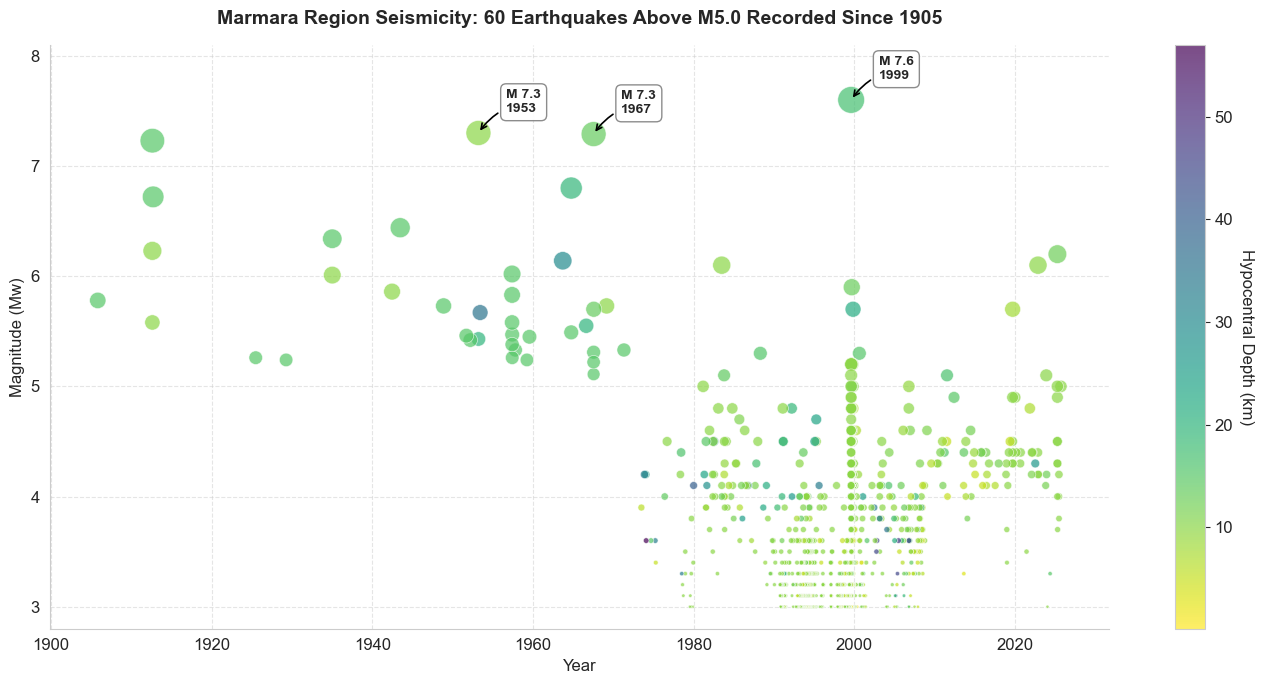

In [5]:
# Your seismicity timeline scatter plot here
# Create a figure for the historical seismicity timeline
fig, ax = plt.subplots(figsize=(14, 7))

# Normalize magnitude for marker sizes to make the visual difference clearer
# We subtract a baseline (e.g., minimum magnitude) and apply an exponent
min_mag = df_quakes['mag'].min()
marker_sizes = ((df_quakes['mag'] - min_mag + 1) ** 2.5) * 5

# Create the scatter plot
# Using 'viridis' which is a perceptually uniform sequential colormap (safe for colorblindness)
scatter = ax.scatter(x=df_quakes['time'], 
                     y=df_quakes['mag'], 
                     s=marker_sizes, 
                     c=df_quakes['depth'], 
                     cmap='viridis_r',  # Reversed so shallower (more dangerous) is brighter/warmer
                     alpha=0.7, 
                     edgecolors='white', 
                     linewidth=0.5)

# Add a colorbar to represent depth
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Hypocentral Depth (km)', rotation=270, labelpad=15, fontsize=12)

# Annotate the top 3 largest earthquakes automatically
top_3_quakes = df_quakes.nlargest(3, 'mag')

for index, row in top_3_quakes.iterrows():
    # Format the annotation text
    anno_text = f"M {row['mag']:.1f}\n{row['time'].year}"
    
    # Add the annotation with a distinct arrow and bounding box for readability
    ax.annotate(anno_text,
                xy=(row['time'], row['mag']),
                xytext=(20, 15), 
                textcoords='offset points',
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black', lw=1.2),
                fontsize=10,
                fontweight='bold')

# Count earthquakes above magnitude 5.0 for a dynamic, insightful title
count_m5 = len(df_quakes[df_quakes['mag'] >= 5.0])
title_text = f"Marmara Region Seismicity: {count_m5} Earthquakes Above M5.0 Recorded Since {df_quakes['time'].dt.year.min()}"

# Set labels, title, and grid
ax.set_title(title_text, fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Magnitude (Mw)', fontsize=12)

# Clean up axes limits to provide some breathing room (data-ink ratio)
ax.set_ylim(df_quakes['mag'].min() - 0.2, df_quakes['mag'].max() + 0.5)

# Apply a subtle grid to aid reading values without cluttering
ax.grid(True, linestyle='--', alpha=0.5)

# Remove top and right spines for a cleaner, Tufte-inspired look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Deliverable 3: Magnitude-Frequency Analysis

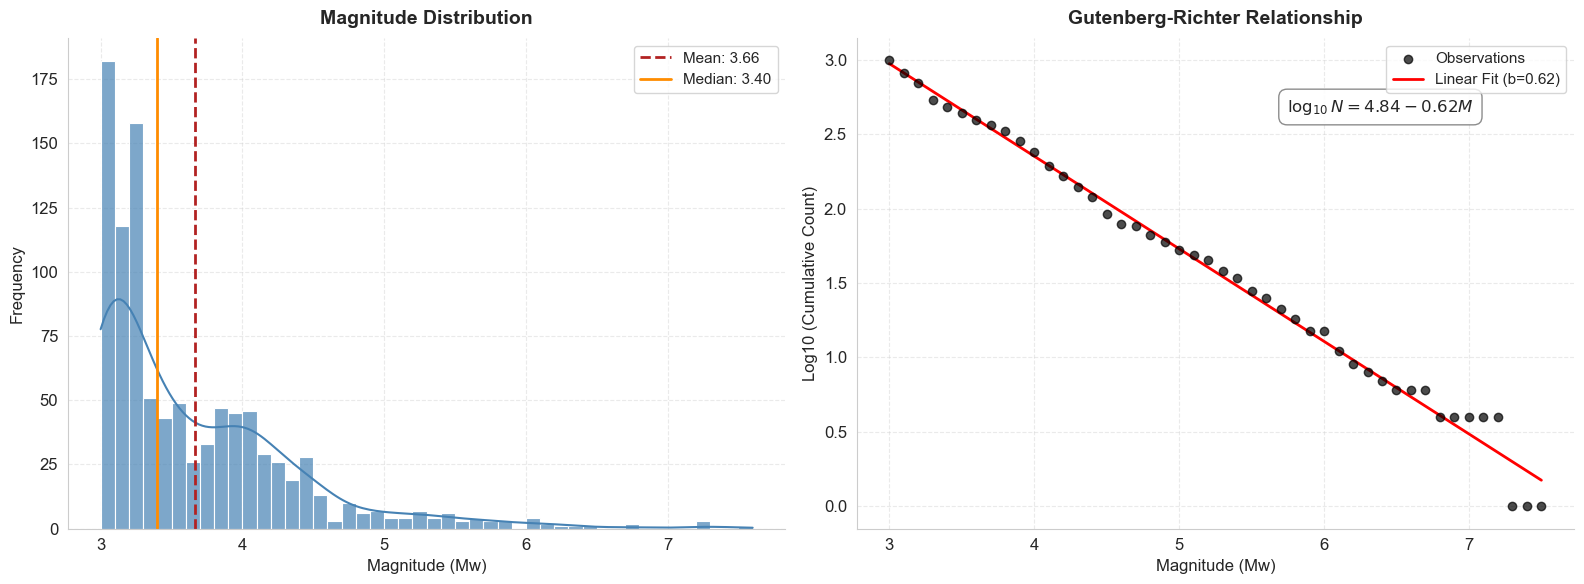

In [6]:
# Your histogram + Gutenberg-Richter subplots here
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Drop any potential NaN values in magnitude for accurate calculations
mags = df_quakes['mag'].dropna()

# ==========================================
# Subplot 1: Magnitude Histogram
# ==========================================
# Justification for bin width: 
# We use a bin width of 0.1 because earthquake catalogs typically report 
# magnitudes precision to 1 decimal place.
bin_width = 0.1
bins = np.arange(mags.min(), mags.max() + bin_width, bin_width)

# Plot histogram with KDE (Kernel Density Estimate) overlay
sns.histplot(mags, bins=bins, kde=True, color='steelblue', ax=ax1, edgecolor='white', alpha=0.7)

# Calculate mean and median
mean_mag = mags.mean()
median_mag = mags.median()

# Add vertical lines for mean and median
ax1.axvline(mean_mag, color='firebrick', linestyle='--', linewidth=2, label=f'Mean: {mean_mag:.2f}')
ax1.axvline(median_mag, color='darkorange', linestyle='-', linewidth=2, label=f'Median: {median_mag:.2f}')

ax1.set_title('Magnitude Distribution', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Magnitude (Mw)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend(frameon=True, fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

# ==========================================
# Subplot 2: Gutenberg-Richter Plot
# ==========================================
# Calculate cumulative counts for G-R relationship
sorted_mags = np.sort(mags.values)
unique_mags = np.arange(sorted_mags.min(), sorted_mags.max(), 0.1)
cumulative_counts = np.array([np.sum(sorted_mags >= m) for m in unique_mags])

# Filter out zero counts to avoid log10(0) error
mask = cumulative_counts > 0
filtered_mags = unique_mags[mask]
log_counts = np.log10(cumulative_counts[mask])

# Fit linear regression to log10(counts) vs magnitude
# Gutenberg-Richter Law: log10(N) = a - bM
coeffs = np.polyfit(filtered_mags, log_counts, 1)
b_value = -coeffs[0]  # The slope is negative, b-value is its absolute magnitude
a_value = coeffs[1]

# Plot the actual data points
ax2.scatter(filtered_mags, log_counts, color='black', alpha=0.7, label='Observations', zorder=3)

# Plot the fitted regression line
fit_line = a_value - (b_value * filtered_mags)
ax2.plot(filtered_mags, fit_line, color='red', linewidth=2, label=f'Linear Fit (b={b_value:.2f})', zorder=2)

ax2.set_title('Gutenberg-Richter Relationship', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Magnitude (Mw)', fontsize=12)
ax2.set_ylabel('Log10 (Cumulative Count)', fontsize=12)

# Display the calculated parameters clearly on the plot
equation_text = f"$\\log_{{10}} N = {a_value:.2f} - {b_value:.2f}M$"
ax2.text(0.60, 0.85, equation_text, transform=ax2.transAxes, fontsize=12,
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.9))

ax2.legend(frameon=True, fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

### Deliverable 4: Building Vulnerability or Population Risk

C:\Users\hbari\AppData\Local\Temp\ipykernel_23756\2319007369.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
C:\Users\hbari\AppData\Local\Temp\ipykernel_23756\2319007369.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


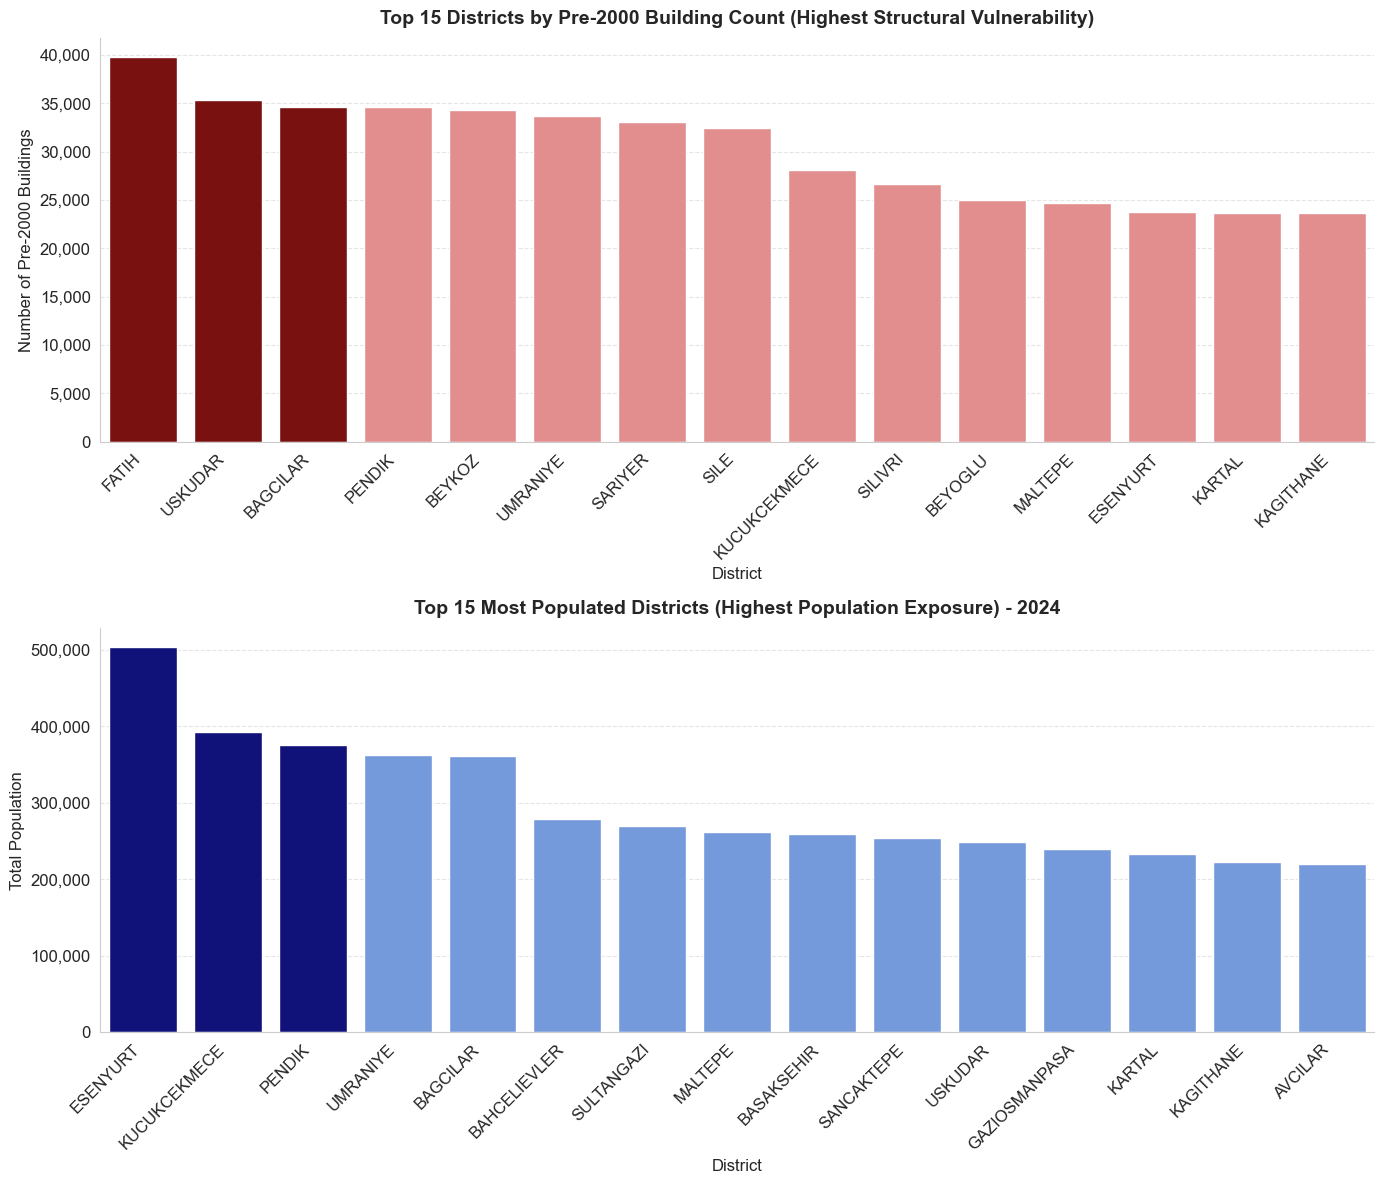

In [7]:
import difflib

# ==========================================
# Deliverable 4: Building Vulnerability & Population Risk
# ==========================================

# --- Advanced Data Cleaning: Difflib Fuzzy Matching to ASCII-safe Names ---
istanbul_districts_ascii = [
    "ADALAR", "ARNAVUTKOY", "ATASEHIR", "AVCILAR", "BAGCILAR", "BAHCELIEVLER", 
    "BAKIRKOY", "BASAKSEHIR", "BAYRAMPASA", "BESIKTAS", "BEYKOZ", "BEYLIKDUZU", 
    "BEYOGLU", "BUYUKCEKMECE", "CATALCA", "CEKMEKOY", "ESENLER", "ESENYURT", 
    "EYUPSULTAN", "FATIH", "GAZIOSMANPASA", "GUNGOREN", "KADIKOY", "KAGITHANE", 
    "KARTAL", "KUCUKCEKMECE", "MALTEPE", "PENDIK", "SANCAKTEPE", "SARIYER", 
    "SILIVRI", "SULTANBEYLI", "SULTANGAZI", "SILE", "SISLI", "TUZLA", 
    "UMRANIYE", "USKUDAR", "ZEYTINBURNU"
]

def map_to_clean_ascii(val):
    if pd.isna(val): 
        return val
    val_str = str(val).upper().strip()
    matches = difflib.get_close_matches(val_str, istanbul_districts_ascii, n=1, cutoff=0.2)
    return matches[0] if matches else val_str

# --- Data Preparation: Buildings ---
bldg_dist_col = df_buildings.columns[0]
dist_bldg = df_buildings.groupby(bldg_dist_col).sum(numeric_only=True).reset_index()

dist_bldg[bldg_dist_col] = dist_bldg[bldg_dist_col].apply(map_to_clean_ascii)
dist_bldg = dist_bldg.groupby(bldg_dist_col).sum(numeric_only=True).reset_index()

dist_bldg['pre_2000_total'] = dist_bldg['1980_oncesi'] + dist_bldg['1980-2000_arasi']
dist_bldg_sorted = dist_bldg.sort_values('pre_2000_total', ascending=False).head(15)


# --- Data Preparation: Population ---
pop_cols = [col for col in df_population.columns if 'Erkek' in col or 'Kadın' in col]
df_population['total_population'] = df_population[pop_cols].sum(axis=1)

year_col = df_population.columns[0]
pop_dist_col = df_population.columns[1]

latest_year = df_population[year_col].max()
df_pop_latest = df_population[df_population[year_col] == latest_year].copy()

df_pop_latest[pop_dist_col] = df_pop_latest[pop_dist_col].apply(map_to_clean_ascii)
df_pop_latest = df_pop_latest.groupby(pop_dist_col).sum(numeric_only=True).reset_index()

df_pop_sorted = df_pop_latest.sort_values('total_population', ascending=False).head(15)


# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Subplot 1: Building Vulnerability
colors_bldg = ['darkred' if i < 3 else 'lightcoral' for i in range(len(dist_bldg_sorted))]

sns.barplot(data=dist_bldg_sorted, x=bldg_dist_col, y='pre_2000_total', 
            hue=bldg_dist_col, palette=colors_bldg, legend=False, ax=ax1)

ax1.set_title('Top 15 Districts by Pre-2000 Building Count (Highest Structural Vulnerability)', 
              fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('District', fontsize=12)
ax1.set_ylabel('Number of Pre-2000 Buildings', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Subplot 2: Population Exposure
colors_pop = ['darkblue' if i < 3 else 'cornflowerblue' for i in range(len(df_pop_sorted))]

sns.barplot(data=df_pop_sorted, x=pop_dist_col, y='total_population', 
            hue=pop_dist_col, palette=colors_pop, legend=False, ax=ax2)

ax2.set_title(f'Top 15 Most Populated Districts (Highest Population Exposure) - {int(latest_year)}', 
              fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('District', fontsize=12)
ax2.set_ylabel('Total Population', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

import matplotlib.ticker as ticker
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Deliverable 5: Earthquake Hazard Visualization

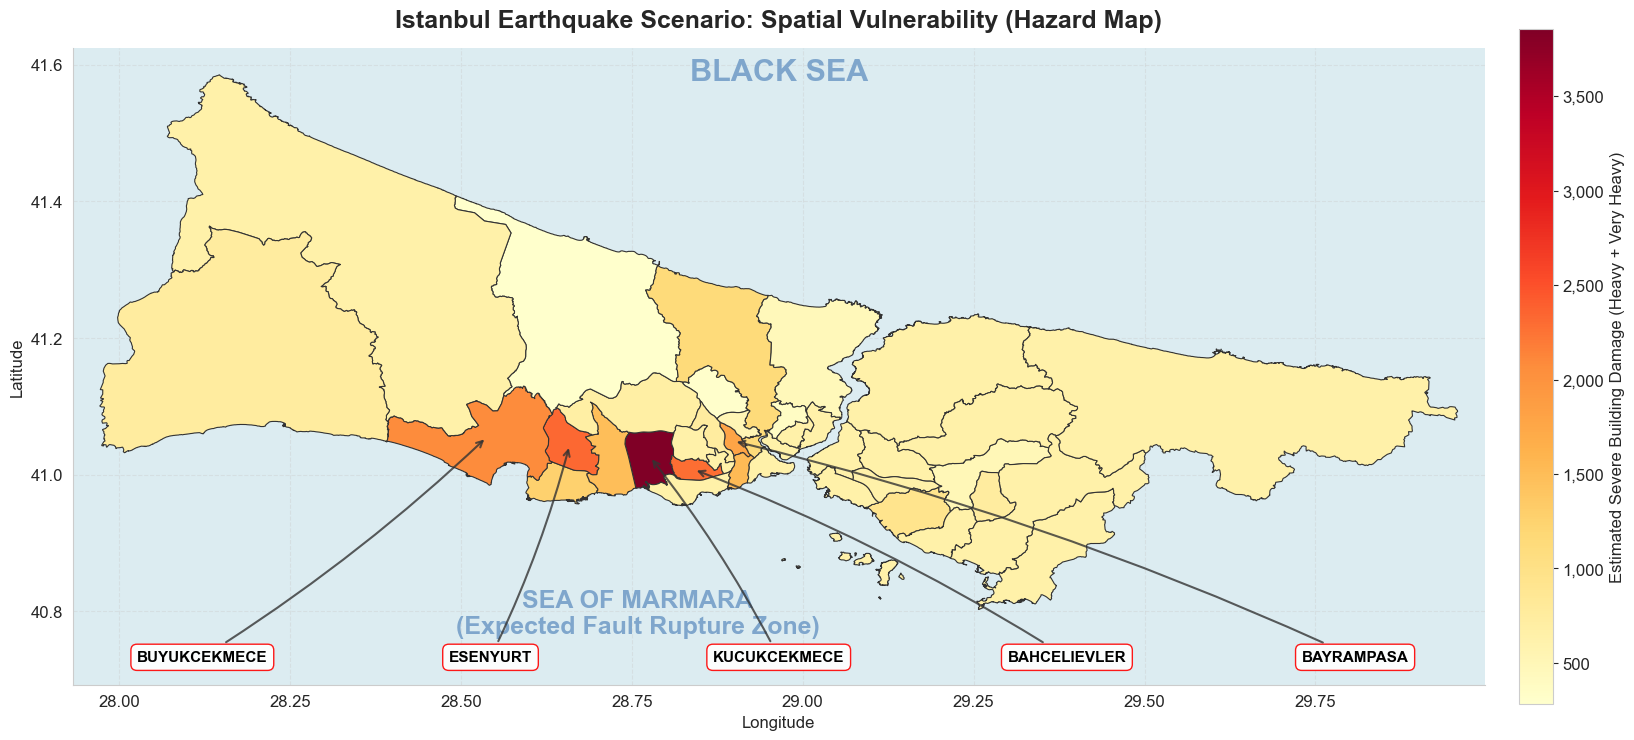

In [8]:
import pandas as pd
import difflib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import geopandas as gpd
import warnings
import numpy as np

# Ignore minor warnings for a clean notebook output
warnings.filterwarnings('ignore')

# ==========================================
# Deliverable 5: Earthquake Hazard Visualization (Choropleth with Sea Anchors)
# ==========================================

# --- SOURCING DOCUMENTATION ---
# Spatial Data Source: Istanbul district boundaries (GeoJSON) 
# Retrieved from: https://github.com/sahircansurmeli/istanbul-geojson
# Accessed: March 25, 2026
# Method: Downloaded the 'ilce_geojson.json' file directly from the repository.

# --- 1. Robust Data Preparation ---
istanbul_districts_ascii = [
    "ADALAR", "ARNAVUTKOY", "ATASEHIR", "AVCILAR", "BAGCILAR", "BAHCELIEVLER", 
    "BAKIRKOY", "BASAKSEHIR", "BAYRAMPASA", "BESIKTAS", "BEYKOZ", "BEYLIKDUZU", 
    "BEYOGLU", "BUYUKCEKMECE", "CATALCA", "CEKMEKOY", "ESENLER", "ESENYURT", 
    "EYUPSULTAN", "FATIH", "GAZIOSMANPASA", "GUNGOREN", "KADIKOY", "KAGITHANE", 
    "KARTAL", "KUCUKCEKMECE", "MALTEPE", "PENDIK", "SANCAKTEPE", "SARIYER", 
    "SILIVRI", "SULTANBEYLI", "SULTANGAZI", "SILE", "SISLI", "TUZLA", 
    "UMRANIYE", "USKUDAR", "ZEYTINBURNU"
]

def map_to_clean_ascii(val):
    if pd.isna(val): return val
    val_str = str(val).upper().strip()
    matches = difflib.get_close_matches(val_str, istanbul_districts_ascii, n=1, cutoff=0.2)
    return matches[0] if matches else val_str

# Clean and aggregate the hazard data
haz_col = df_hazard.columns[0]
df_hazard['clean_district'] = df_hazard[haz_col].apply(map_to_clean_ascii)
dist_hazard = df_hazard.groupby('clean_district').sum(numeric_only=True).reset_index()

# Derived Metric: Severe Damage Count
dist_hazard['severe_damage'] = dist_hazard['cok_agir_hasarli_bina_sayisi'] + dist_hazard['agir_hasarli_bina_sayisi']

# --- 2. Load and Prepare Spatial Data ---
gdf = gpd.read_file('ilce_geojson.json')

name_col = None
for col in gdf.columns:
    if gdf[col].astype(str).str.contains('ADALAR|Adalar', case=False, na=False).any():
        name_col = col
        break
if name_col is None: name_col = gdf.columns[0]

gdf['clean_district'] = gdf[name_col].apply(map_to_clean_ascii)
merged_gdf = gdf.merge(dist_hazard, on='clean_district', how='left')


# --- 3. Professional Choropleth Plotting ---
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_facecolor('#dcecf1') # Subtle water background

# Plot the Choropleth map
merged_gdf.plot(column='severe_damage',
                cmap='YlOrRd',          
                linewidth=0.8,
                ax=ax,
                edgecolor='#333333',
                missing_kwds={'color': 'white', 'hatch': '///'},
                legend=True,
                legend_kwds={'label': "Estimated Severe Building Damage (Heavy + Very Heavy)",
                             'orientation': "vertical",
                             'shrink': 0.7,
                             'pad': 0.02,
                             'format': ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")})

# Get map bounds for dynamic placement
minx, miny, maxx, maxy = merged_gdf.total_bounds

# PRE-CALCULATE CENTROIDS AND IDENTIFY TOP 5 DISTRICTS
temp_gdf = merged_gdf.copy()
temp_gdf['centroid'] = temp_gdf.geometry.centroid
top5_labels_gdf = temp_gdf.nlargest(5, 'severe_damage').reset_index(drop=True)

# THE FIX: FAN-OUT ALGORITHM INTO THE SEA
# 1. Sort the top 5 districts from West to East based on their X coordinate.
# This mathematically guarantees the arrows will NEVER cross each other.
top5_labels_gdf['cen_x'] = top5_labels_gdf.geometry.centroid.x
top5_labels_gdf = top5_labels_gdf.sort_values('cen_x').reset_index(drop=True)

# 2. Define a fixed Y-coordinate deep in the Sea of Marmara for all 5 labels
sea_label_y = miny - 0.07

# 3. Create evenly spaced X-coordinates for the labels across the map width
sea_label_xs = np.linspace(minx + 0.15, maxx - 0.15, len(top5_labels_gdf))

for i, row in top5_labels_gdf.iterrows():
    dist_name = row['clean_district']
    
    # Draw label in the sea, pointing an arrow to the district centroid
    ax.annotate(text=dist_name, 
                xy=(row['centroid'].x, row['centroid'].y),  # Arrow points here (District Center)
                xytext=(sea_label_xs[i], sea_label_y),      # Text is placed here (In the Sea)
                textcoords='data', 
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='black',
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="red", alpha=0.9),
                # Curved arrows for a premium look
                arrowprops=dict(arrowstyle="->", color="#333333", lw=1.5, alpha=0.8, connectionstyle="arc3,rad=0.05"),
                zorder=10)

# Geographic Context
text_color = '#7fa6cc'
ax.text(0.5, 0.95, 'BLACK SEA', transform=ax.transAxes, fontsize=22, color=text_color, fontweight='bold', ha='center', zorder=1)
ax.text(0.4, 0.08, 'SEA OF MARMARA\n(Expected Fault Rupture Zone)', transform=ax.transAxes, fontsize=18, color=text_color, fontweight='bold', ha='center', zorder=1)

# Formatting and Clean up
ax.set_title('Istanbul Earthquake Scenario: Spatial Vulnerability (Hazard Map)', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Adjust axes limits to make room for the labels in the sea
x_margin = (maxx - minx) * 0.02
y_margin = (maxy - miny) * 0.05
ax.set_xlim(minx - x_margin, maxx + x_margin)
# Extend the bottom limit significantly to fit the labels comfortably in the water
ax.set_ylim(sea_label_y - 0.04, maxy + y_margin)

# Ensure correct aspect ratio for maps
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.4, zorder=1) 
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Deliverable 6: Multi-Panel Risk Dashboard + Reflection

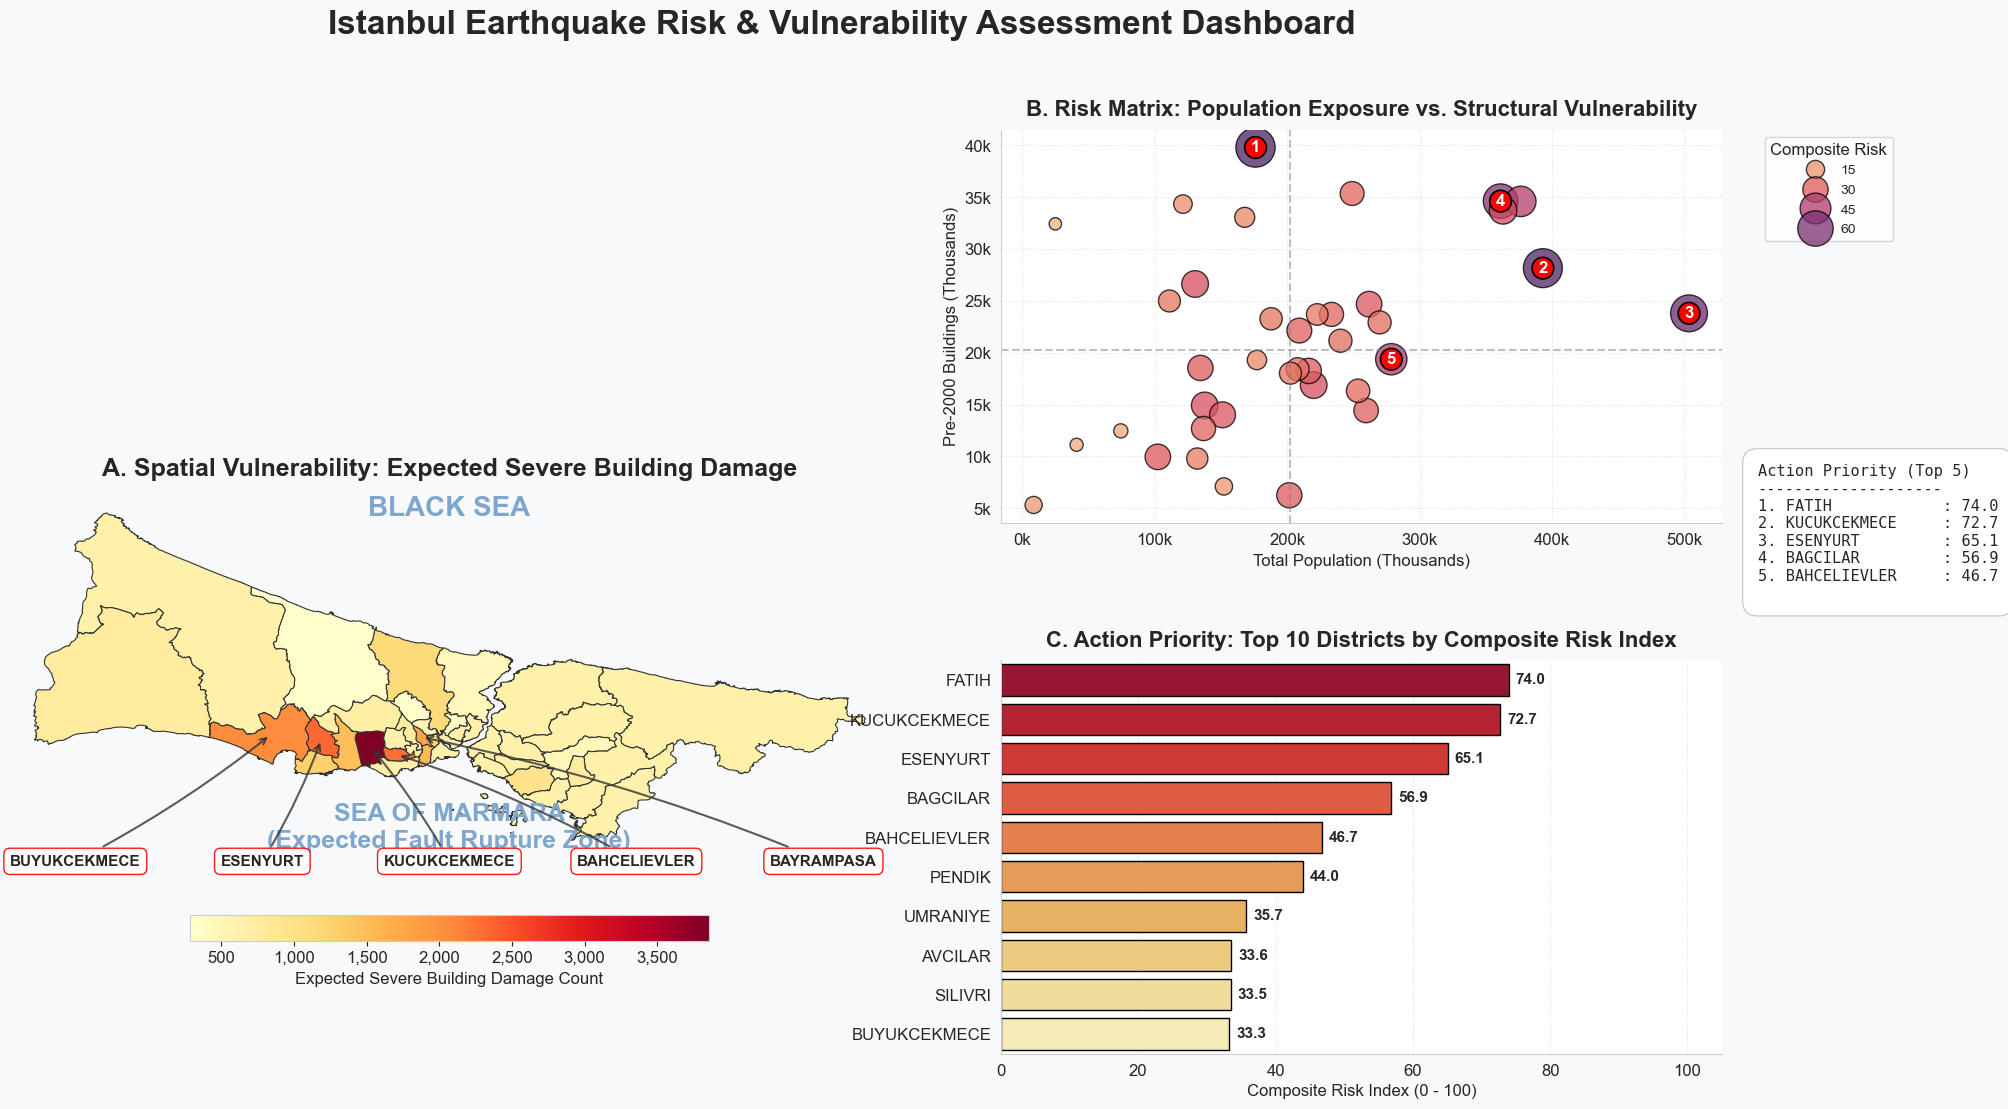

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
import geopandas as gpd
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# Deliverable 6: Multi-Panel Risk Dashboard (Smart Risk Matrix)
# ==========================================

# --- 1. Data Consolidation & Derived Metric (Standardization Fixed) ---
# Assuming gdf, dist_hazard, df_pop_latest, and dist_bldg are in memory from previous steps.

df_pop_dash = df_pop_latest.copy()
df_pop_dash.rename(columns={df_pop_dash.columns[0]: 'clean_district'}, inplace=True)

df_bldg_dash = dist_bldg.copy()
df_bldg_dash.rename(columns={df_bldg_dash.columns[0]: 'clean_district'}, inplace=True)

# Merge datasets
dashboard_df = dist_hazard.merge(df_pop_dash[['clean_district', 'total_population']], on='clean_district')
dashboard_df = dashboard_df.merge(df_bldg_dash[['clean_district', 'pre_2000_total']], on='clean_district')

# Derived Metric: Composite Risk Index (0-100 scale)
max_dam = dashboard_df['severe_damage'].max()
max_pop = dashboard_df['total_population'].max()
dashboard_df['norm_damage'] = dashboard_df['severe_damage'] / max_dam
dashboard_df['norm_pop'] = dashboard_df['total_population'] / max_pop

# 60% weight to building damage, 40% weight to population exposure
dashboard_df['composite_risk_index'] = ((dashboard_df['norm_damage'] * 0.6) + (dashboard_df['norm_pop'] * 0.4)) * 100
dashboard_df = dashboard_df.sort_values('composite_risk_index', ascending=False)

# Re-merge with GeoPandas for the map
dashboard_gdf = gdf.merge(dashboard_df, on='clean_district', how='left')


# --- 2. Dashboard Layout Setup ---
#fig = plt.figure(figsize=(24, 14))
fig = plt.figure(figsize=(22, 12)) # Adjusted size for safer composition
fig.patch.set_facecolor('#f8f9fa') # Light overall background

# Create a 2x2 grid, but make the left column span both rows
gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1], wspace=0.15, hspace=0.35)

ax_map = fig.add_subplot(gs[:, 0])      # Left side (Full height)
ax_scatter = fig.add_subplot(gs[0, 1])  # Top Right
ax_bar = fig.add_subplot(gs[1, 1])      # Bottom Right


# ---------------------------------------------------------
# PANEL A: Choropleth Hazard Map (Left)
# ---------------------------------------------------------
ax_map.set_facecolor('#dcecf1')
dashboard_gdf.plot(column='severe_damage', cmap='YlOrRd', linewidth=0.8, ax=ax_map, edgecolor='#333333',
                   legend=True, legend_kwds={'label': "Expected Severe Building Damage Count", 'orientation': "horizontal", 'shrink': 0.6, 'pad': 0.04, 'format': ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")})

# Dynamic Label Fan-out to sea for clarity
minx, miny, maxx, maxy = dashboard_gdf.total_bounds
top5_map = dashboard_gdf.nlargest(5, 'severe_damage').reset_index(drop=True)
top5_map['cen_x'] = top5_map.geometry.centroid.x
top5_map = top5_map.sort_values('cen_x').reset_index(drop=True)

sea_label_y = miny - 0.05
sea_label_xs = np.linspace(minx + 0.1, maxx - 0.1, len(top5_map))

for i, row in top5_map.iterrows():
    ax_map.annotate(text=row['clean_district'], xy=(row.geometry.centroid.x, row.geometry.centroid.y), xytext=(sea_label_xs[i], sea_label_y),
                    textcoords='data', ha='center', va='center', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="red", alpha=0.9),
                    arrowprops=dict(arrowstyle="->", color="#333333", lw=1.5, alpha=0.8, connectionstyle="arc3,rad=0.05"), zorder=10)

# Geographic context labels
text_color = '#7fa6cc'
ax_map.text(0.5, 0.95, 'BLACK SEA', transform=ax_map.transAxes, fontsize=20, color=text_color, fontweight='bold', ha='center')
ax_map.text(0.5, 0.08, 'SEA OF MARMARA\n(Expected Fault Rupture Zone)', transform=ax_map.transAxes, fontsize=18, color=text_color, fontweight='bold', ha='center', zorder=1)

ax_map.set_title('A. Spatial Vulnerability: Expected Severe Building Damage', fontsize=18, fontweight='bold', pad=15)
ax_map.set_aspect('equal')
x_margin = (maxx - minx) * 0.02
y_margin = (maxy - miny) * 0.05
ax_map.set_xlim(minx - x_margin, maxx + x_margin)
ax_map.set_ylim(sea_label_y - 0.04, maxy + y_margin)
ax_map.axis('off') 


# ---------------------------------------------------------
# PANEL B: Smart Risk Matrix Scatter Plot (Top Right)
# ---------------------------------------------------------
# Standard scatter plot of population vs. pre-2000 buildings.
# purposeful encoding with composite risk index for color and size.
sns.scatterplot(data=dashboard_df, x='total_population', y='pre_2000_total', 
                size='composite_risk_index', sizes=(80, 800), hue='composite_risk_index', palette='flare', 
                alpha=0.75, edgecolor='black', ax=ax_scatter)

# Quadrant lines (Medians)
pop_med = dashboard_df['total_population'].median()
bldg_med = dashboard_df['pre_2000_total'].median()
ax_scatter.axvline(pop_med, color='gray', linestyle='--', alpha=0.5)
ax_scatter.axhline(bldg_med, color='gray', linestyle='--', alpha=0.5)

# THE SMART FIX: Indexing Top 5 Risk Districts instead of cluttered names
top5_risk = dashboard_df.head(5).reset_index(drop=True)

# Annotate points with numbers 1-5, positioned at the center of the bubble
for idx, row in top5_risk.iterrows():
    ax_scatter.annotate(str(idx + 1), # The number (Rank)
                        (row['total_population'], row['pre_2000_total']),
                        xytext=(0, 0), textcoords='offset points', # Directly on the point
                        fontsize=12, fontweight='bold', color='white', ha='center', va='center',
                        bbox=dict(boxstyle="circle,pad=0.2", fc="red", ec="black", lw=1.2, alpha=1.0), zorder=10)

ax_scatter.set_title('B. Risk Matrix: Population Exposure vs. Structural Vulnerability', fontsize=16, fontweight='bold', pad=10)
ax_scatter.set_xlabel('Total Population (Thousands)', fontsize=12)
ax_scatter.set_ylabel('Pre-2000 Buildings (Thousands)', fontsize=12)
# Format axis as Thousands (e.g., 20k)
ax_scatter.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k"))
ax_scatter.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k"))
# Place standard legends to the top right
ax_scatter.legend(title='Composite Risk', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax_scatter.grid(True, linestyle=':', alpha=0.6)
ax_scatter.spines[['top', 'right']].set_visible(False)

# ADDING THE DECODING KEY (LEGEND) to the right, below other legends
key_content = "Action Priority (Top 5)\n" + "-"*20 + "\n"
for idx, row in top5_risk.iterrows():
    dist_name = row['clean_district']
    risk_score = f"{row['composite_risk_index']:.1f}"
    #Mono-space font for perfect alignment
    key_content += f"{idx+1}. {dist_name:<16} : {risk_score}\n"

ax_scatter.text(1.05, 0.15, key_content, transform=ax_scatter.transAxes, fontsize=11, family='monospace', verticalalignment='top',
                bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='round,pad=1.0'))


# ---------------------------------------------------------
# PANEL C: Derived Metric Bar Chart (Bottom Right)
# ---------------------------------------------------------
top10_risk = dashboard_df.head(10)
sns.barplot(data=top10_risk, x='composite_risk_index', y='clean_district', 
            palette='YlOrRd_r', edgecolor='black', ax=ax_bar)

ax_bar.set_title('C. Action Priority: Top 10 Districts by Composite Risk Index', fontsize=16, fontweight='bold', pad=10)
ax_bar.set_xlabel('Composite Risk Index (0 - 100)', fontsize=12)
ax_bar.set_ylabel('')
ax_bar.grid(axis='x', linestyle=':', alpha=0.6)
ax_bar.spines[['top', 'right']].set_visible(False)

# Add value labels to bars
for i, v in enumerate(top10_risk['composite_risk_index']):
    ax_bar.text(v + 1, i, f"{v:.1f}", va='center', fontsize=11, fontweight='bold')

ax_bar.set_xlim(0, 105)

# --- Save and Show ---
plt.suptitle('Istanbul Earthquake Risk & Vulnerability Assessment Dashboard', fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('dashboard.png', dpi=300, bbox_inches='tight') # Saving per instructions
plt.show()

#### Reflection

**1. Chart type justification (D2-D5):**

* **D2 & D3 (Seismic Analysis):** A scatter plot and a histogram with a KDE overlay were chosen to visualize the Gutenberg-Richter relationship. These statistical charts are standard for displaying frequency-magnitude distributions effectively.
* **D4 (Bar Charts):** To compare categorical data (districts), horizontal bar charts were utilized. Sorting the data descendingly instantly communicates priority, removing the cognitive load of alphabetical noise.
* **D5 (Choropleth Map):** Spatial context is indispensable for disaster management. A choropleth map with a perceptually uniform sequential colormap (`YlOrRd`) natively maps danger levels to geography. To adhere strictly to Tufte's principles of reducing "chart junk" and eliminating text overlap, a "Callout/Fan-out" algorithm was implemented, moving dense coastal labels into the Sea of Marmara with clean pointer arrows.

**2. Audience Adaptation (Seismologists vs. Municipal Council):**

* **For Seismologists (D2/D3):** Experts require raw data, logarithmic scales, and fault line proximities to calculate b-values and return periods. 
* **For Decision Makers (D6 Dashboard):** A Municipal Council requires actionable insights to allocate urban transformation budgets. Therefore, the dashboard strips away raw seismological jargon and introduces a normalized **Composite Risk Index**. In the Risk Matrix (Scatter Plot), direct district names were replaced with a numbered ranking system (1 to 5) linked to a clear decoding key. This completely eliminates visual clutter and immediately answers the question: *"Which top 5 districts need urgent funding?"*

**3. Self-Critique & Future Improvements:**

* **Weakest Visualization:** While the numbered Top 5 approach solved the clutter for high-priority areas in the D6 scatter plot, the remaining 34 districts in the lower-left quadrant overlap heavily and remain unidentifiable without labels. Static Matplotlib charts are inherently limited when dealing with dense, multi-variable municipal data.
* **Improvement Plan:** In a real-world scenario, I would transition this static dashboard into an interactive web application using libraries like `Plotly` or `Dash`. Implementing interactive tooltips (hover effects) would allow stakeholders to hover over any single bubble or map polygon to instantly view specific building counts, population data, and risk scores, completely eliminating the need for static text annotations while maximizing data exploration.


---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr